# Lista Prática - Questão 4

In [1]:
from examples.seismic.source import RickerSource, TimeAxis
from examples.seismic import setup_geometry, PointSource, Receiver
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.stiffness.model import ISOSeismicModel
from examples.seismic.stiffness.utils import C_Matrix, D, S, vec
from devito import *
from examples.seismic.stiffness import iso_elastic_setup
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from devito import configuration, norm
configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=2
time_order=2

## Definição do modelo

### Dimensões do modelo

O modelo possui dimensões $w \times h = 1500 \mathrm{m} \times 1500 \mathrm{m}$, e um espaçamento de $\Delta x = \Delta z = 2.5$ m. Logo, a malha deverá ter 
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{1500 \mathrm{m}}{2.5 \mathrm{m}} + 1 = 601
$$
pontos ao longo do eixo x, e
$$
n_z = \frac{h}{\Delta z} + 1 = \frac{1500 \mathrm{m}}{10 \mathrm{m}} + 1 = 601
$$
pontos ao longo do eixo z.

In [3]:
shape = (151, 151)
spacing = (10., 10.)
origin = (0., 0.)
# nbl=325
nbl=100

### Parâmetros físicos

In [4]:
vp = 2.0 * np.ones(shape, dtype=np.float32) # Velocidade da onda P em km/s
vs = np.zeros(shape, dtype=np.float32) # Velocidade da onda S em km/s
rho = 2.0 * np.ones(shape, dtype=np.float32) # Densidade em g/cm^3

In [ ]:
model = ISOSeismicModel(vp=vp, vs=vs, b=1/rho, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

In [6]:
# plot_velocity(model)

## Parâmetros da aquisição

### Tempo de aquisição

In [7]:
t0 = 100.  # ms
tn = 2000. # ms
dt = model.critical_dt

time_range = TimeAxis(start=t0, stop=tn, step=dt)

### Geometria

Como o valor mínimo do campo de velocidade é $1.0\ \mathrm{km/s}$, o espaçamento do modelo é $\Delta x = \Delta z = 2.5 \mathrm{m}$ e a ordem do operador de diferenças finitas para as derivadas espaciais é igual a $2$ (F = 10), a frequência máxima $f_{\mathrm{max}}$ da onda propagada deve satisfazer
$$
\begin{aligned}
f_{\mathrm{max}} &\le \frac{\min{(v_P, v_S)}}{F\max{\Delta x, \Delta z}}\\
    &= \frac{1.0\ \mathrm{km/s}}{10 \times 2.5\ \mathrm{m}}\\
    &= 0.04\ \mathrm{kHz}
\end{aligned}
$$
A assinatura da fonte será a fonte de Ricker, que possui uma frequência de pico $f_{\mathrm{peak}} \approx = \dfrac{1}{3} f_{\mathrm{max}}$. Com base nisto, foi escolhida uma frequência máxima de $0.012\ \mathrm{kHz}$, resultando numa frequência de pico igual a $0.004\ \mathrm{kHz}$.

In [8]:
# Frequência de pico da fonte
f0 = 0.004

In [9]:
geometry = AcquisitionGeometry(model, np.array([[0,0]], dtype=model.dtype), np.array([[0,0]], dtype=model.dtype), t0, tn)
# geometry.resample(dt)

In [10]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

src.coordinates.data[0, :] = np.array(model.domain_size) * .5

In [11]:
rec_tauxx = Receiver(name='recTauxx', grid=model.grid, time_range=time_range, npoint=shape[0])
rec_tauzz = Receiver(name='recTauzz', grid=model.grid, time_range=time_range, npoint=shape[0])
rec_tauxz = Receiver(name='recTauxz', grid=model.grid, time_range=time_range, npoint=shape[0])

rec_vx = Receiver(name='recVx', grid=model.grid, time_range=time_range, npoint=shape[0])
rec_vz = Receiver(name='recVz', grid=model.grid, time_range=time_range, npoint=shape[0])

recs = [
    rec_tauxx, rec_tauzz, rec_tauxz, rec_vx, rec_vz
]

for rec in recs:
    rec.coordinates.data[:, 0] = np.linspace(model.origin[0], model.domain_size[0], dtype=model.dtype, num=shape[0])
    rec.coordinates.data[:, 1] = spacing[1]


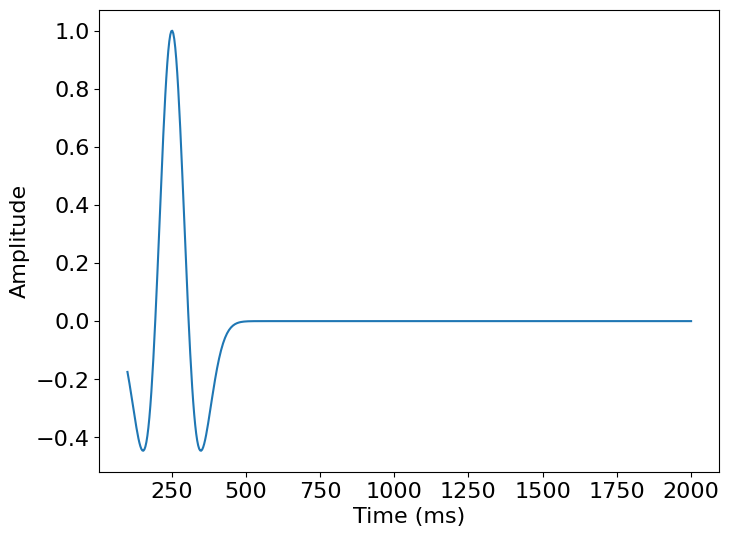

In [12]:
src.show()

#### Posição da fonte

In [13]:
# plot_velocity(model, source=src.coordinates.data, receiver=rec.coordinates.data[::5])

## Resolução da alternativa a)

### Definição da equação da onda elástica de 2ª ordem

Aqui é definida no *Devito* o sistema de equações

$$
\begin{cases}
    \dfrac{\partial \mathbf{\tau}}{\partial t} - CD^T\mathbf{v} = S\\
    \rho\dfrac{\partial \mathbf{v}}{\partial t} - D\mathbf{\tau} = 0
\end{cases}
$$

em que:

- $\mathbf{\tau}$ é o tensor de estresses;
- $C$ é a matriz de rigidez;
- $\mathbf{v}$ é o campo de velocidade de partícula;
- $S$ é o termo fonte;

In [14]:
C = C_Matrix(model,'vp-vs-rho')

In [15]:
# Função pra o campo de pressão
# P = TimeFunction(name="P", grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt, staggered=NODE)
tau = vec(TensorTimeFunction(name='tau', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt))
v = VectorTimeFunction(name='v', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt)


In [16]:
# Sistemas de equações da onda elástica de 1ª ordem
EDP_tau = tau.dt - C* S(v.forward)
EDP_v = 1/model.rho * v.dt - D(tau)

In [17]:
# Expressão para o campo de ondas futuro, P(r, t + dt)

stencil_tau = Eq(tau.forward, solve(EDP_tau, tau.forward))
stencil_v = Eq(v.forward, solve(EDP_v, v.forward))

Com base na expressão acima para o campo $P(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte possui um coeficiente igual a $\Delta t^2 v_P^2$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\Delta t^2 v_P^2 S(\mathbf{x}, t) = \Delta t^2 v_P^2 s(t)\delta(\mathbf{x} - \mathbf{x}_x)$

In [18]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term_xx = src.inject(tau[0].forward, expr = s * src)
src_term_zz = src.inject(tau[1].forward, expr = s * src)
# src_term_xz = src.inject(tau[2].forward, expr = s * src)
src_term = src_term_xx +\
    src_term_zz# +\
    # src_term_xz
# src_term = src_term_xz

In [19]:
# Expressão do termo dos receptores que amostrarão o campo de ondas
rec_tauxx_term = rec_tauxx.interpolate(expr=tau[0].forward)
rec_tauzz_term = rec_tauzz.interpolate(expr=tau[1].forward)
rec_tauxz_term = rec_tauxz.interpolate(expr=tau[2].forward)

rec_vx_term = rec_vx.interpolate(expr=v[0].forward)
rec_vz_term = rec_vz.interpolate(expr=v[1].forward)

rec_term = rec_tauxx_term + rec_tauzz_term + rec_tauxz_term + rec_vx_term + rec_vz_term

### Criação do operador de diferenças finitas

In [20]:
# Criação do operador do Devito
op = Operator([stencil_v, stencil_tau] + src_term + rec_term, subs=model.spacing_map)

In [21]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.39143799999999984, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.00023299999999999946, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section2', rank=None),
                     PerfEntry(time=0.0015720000000000053, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section3', rank=None),
                     PerfEntry(time=0.0015560000000000068, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section4', rank=None),
                     PerfEntry(time=0.0015250000000000062, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section5', rank=None),
                     PerfEntry(time=0.001494000000000008, gflop

### Plotagem do campo de ondas

In [28]:
def plot_wavefield(u, geometry, src_pos, model, title=None, reverse_time=False, t0=0, tn=-1, rec_pos=None):
    shape_pad = np.array(model.shape) + 2 * nbl
    origin_pad = tuple([o - s*nbl for o, s in zip(origin, spacing)])
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data

    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))
    if reverse_time:
        snapshots = np.flip(snapshots)
        amax = np.max(np.abs(udata[0, :, :]))
    
    amax = .1


    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot,:,:].T,
                              cmap="seismic", vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")
            
        nbl_color = 'xkcd:dark blue'
        ax.plot([model.origin[0], model.domain_size[0]], [model.origin[1], model.origin[1]], ls='dashed', color=nbl_color)
        ax.plot([model.domain_size[0], model.domain_size[0]], [model.origin[1], model.domain_size[1]], ls='dashed', color=nbl_color)
        ax.plot([model.origin[0], model.domain_size[0]], [model.domain_size[1], model.domain_size[1]], ls='dashed', color=nbl_color)
        ax.plot([model.origin[0], model.origin[0]], [model.origin[1], model.domain_size[1]], ls='dashed', color=nbl_color)
        # ax.text(0, 0, 'nbl', color=nbl_color)

        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax
    
    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

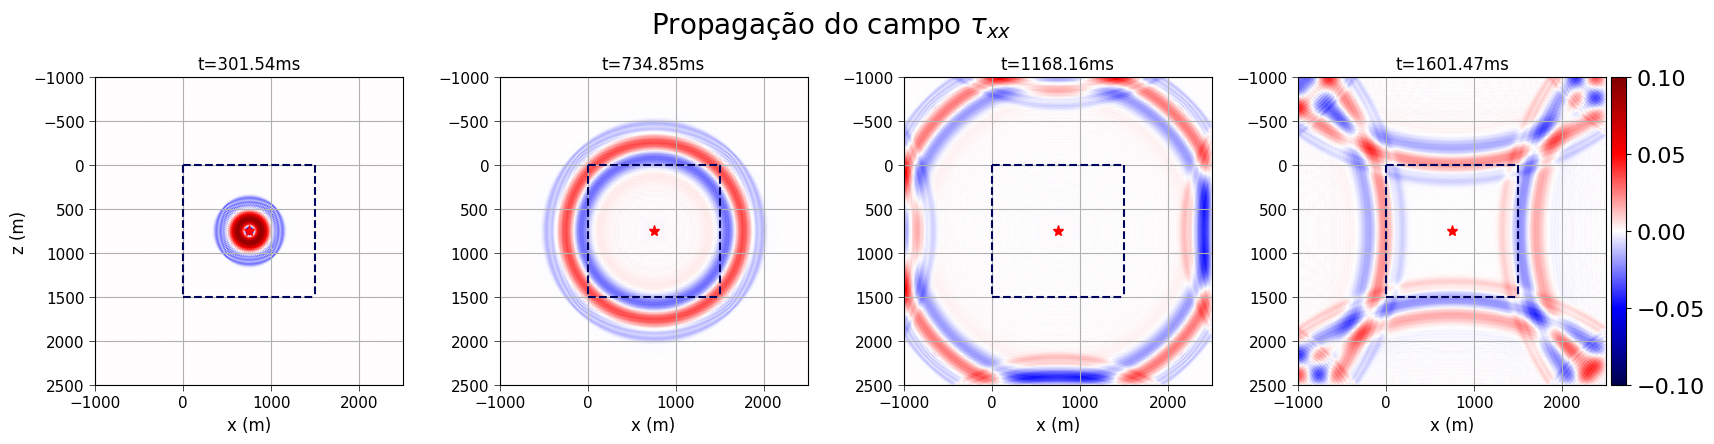

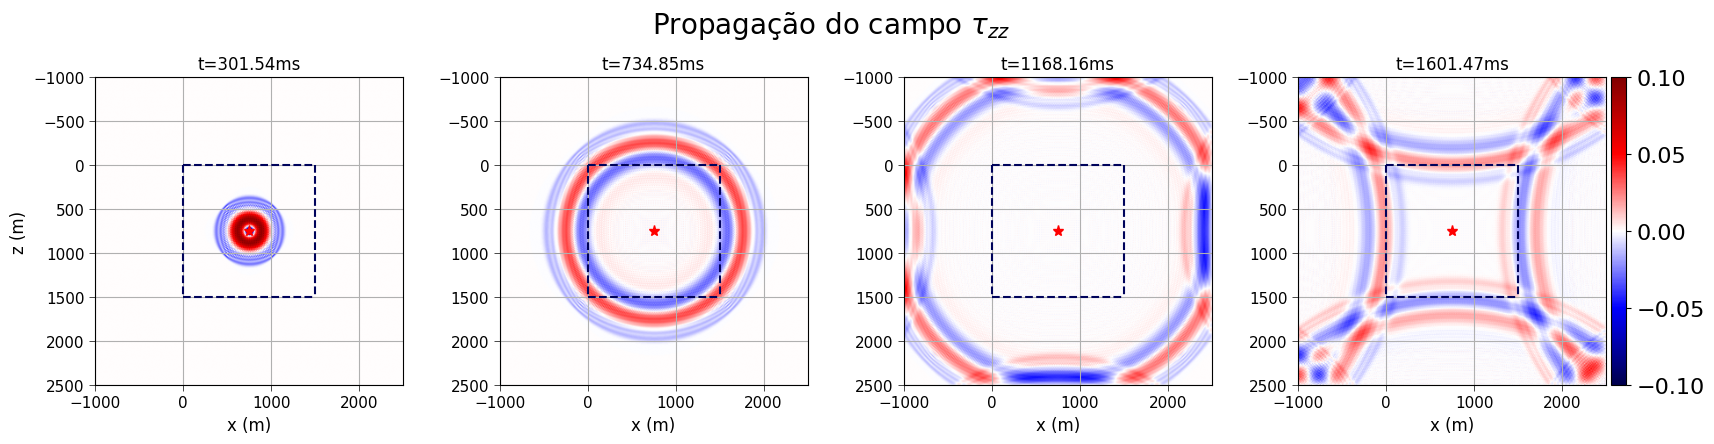

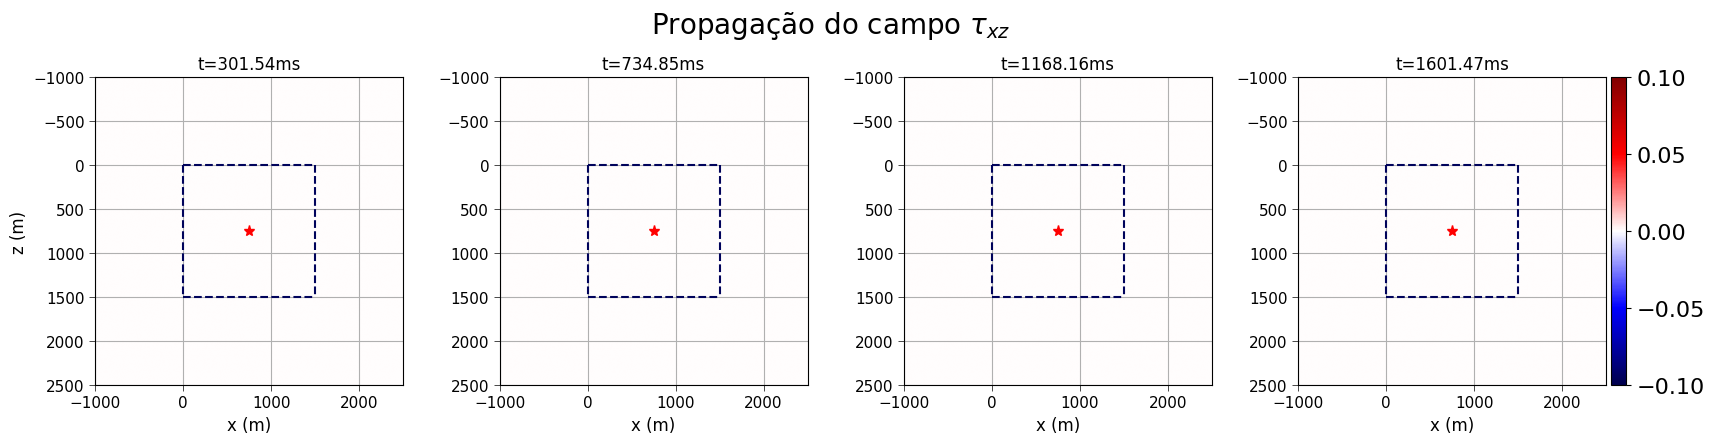

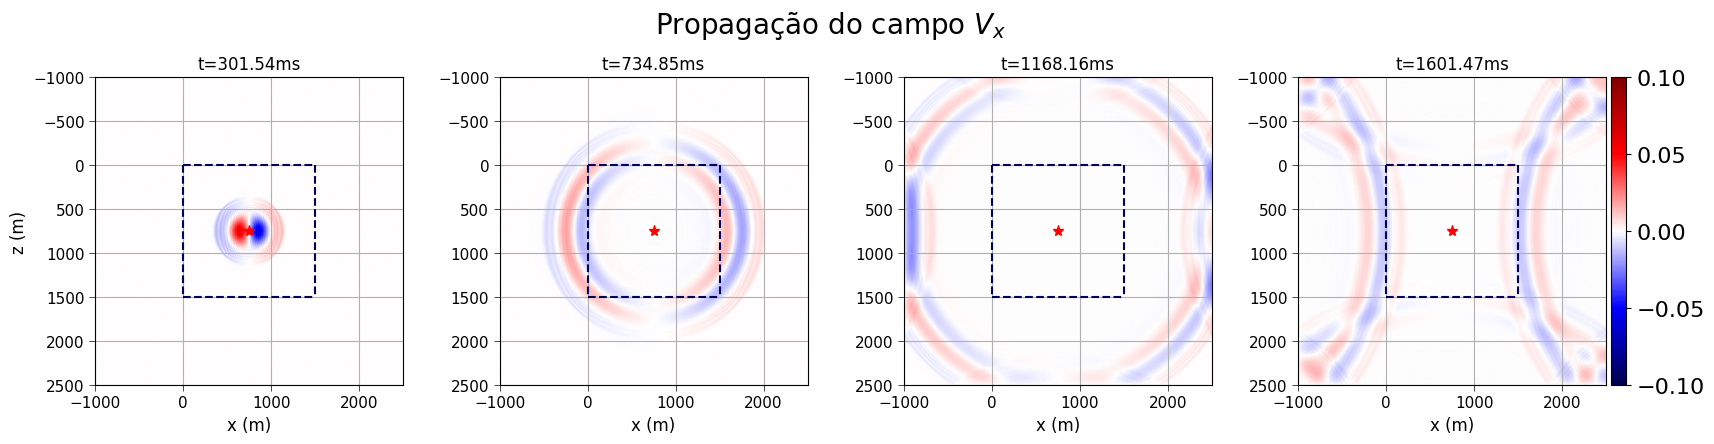

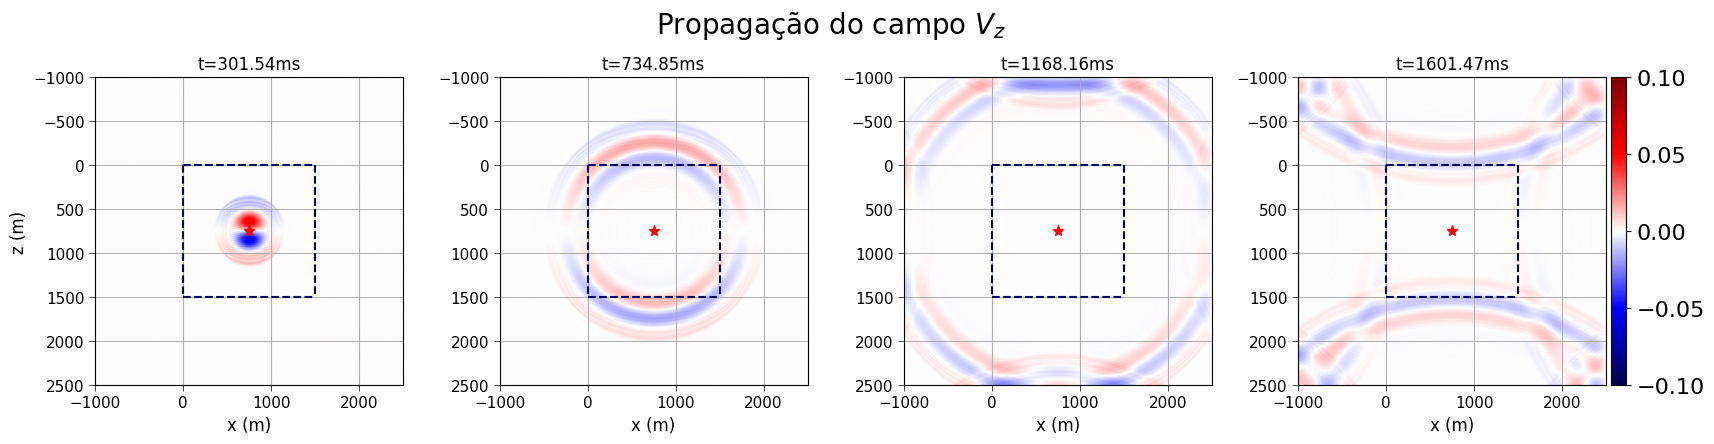

In [29]:
plot_wavefield(tau[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xx}$', t0=300, tn=1600)
plot_wavefield(tau[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{zz}$', t0=300, tn=1600)
plot_wavefield(tau[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xz}$', t0=300, tn=1600)

plot_wavefield(v[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_x$', t0=300, tn=1600)
plot_wavefield(v[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_z$', t0=300, tn=1600)

### Registro Sísmico

In [24]:
def plot_shotrecord(rec, model, t0, tn, colorbar=True, title=None, perc=100):
    scale = np.max(rec) / 10.
    extent = [1e-3*model.origin[0], 1e-3*(model.origin[0] + model.domain_size[0]),
              1e-3*tn, 1e-3*t0]

    # plot = plt.imshow(rec, vmin=-scale, vmax=scale, cmap="gray", extent=extent)
    perc_val = np.percentile(np.array(rec), perc)
    perc_mask = (rec <= perc_val)
    plot = plt.imshow(rec * perc_mask + perc_val*(1 - perc_mask), cmap="gray", extent=extent)
    plt.xlabel('X position (km)')
    plt.ylabel('Time (s)')
    if title:
        plt.title(title)

    # Create aligned colorbar on the right
    if colorbar:
        ax = plt.gca()
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(plot, cax=cax)
    plt.show()

In [25]:
# plot_shotrecord(rec.data, model, t0, tn, title='Registro do campo $P$', perc=98)

## Resolução da alternativa b)

In [26]:
def plot_animated_wavefield(u, geometry, src_pos, model, title=None, reverse_time=False, t0=0, tn=-1, rec_pos=None, nframes=10):
    shape_pad = np.array(model.shape) + 2 * nbl
    origin_pad = tuple([o - s*nbl for o, s in zip(origin, spacing)])
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5), sharex=True)
    # fig.suptitle(title, size=20, y=1.05)

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=nframes, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=nframes, dtype=np.int32)


    udata = u.data

    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))
    if reverse_time:
        snapshots = np.flip(snapshots)
        amax = np.max(np.abs(udata[0, :, :]))
    
    snapshot = snapshots[0]
    wave_plot = ax.imshow(udata[snapshot,:,:].T,
                            cmap="seismic", vmin=-amax,
                vmax=+amax, extent=plt_extent)
    ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
            markersize=8, label="Source")
    
    if type(rec_pos) != type(None):
        ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                markersize=8, label="Receiver")
        
    nbl_color = 'xkcd:dark blue'
    ax.plot([model.origin[0], model.domain_size[0]], [model.origin[1], model.origin[1]], ls='dashed', color=nbl_color)
    ax.plot([model.domain_size[0], model.domain_size[0]], [model.origin[1], model.domain_size[1]], ls='dashed', color=nbl_color)
    ax.plot([model.origin[0], model.domain_size[0]], [model.domain_size[1], model.domain_size[1]], ls='dashed', color=nbl_color)
    ax.plot([model.origin[0], model.origin[0]], [model.origin[1], model.domain_size[1]], ls='dashed', color=nbl_color)
    time_text = ax.text(
        plt_extent[0] + (plt_extent[2] - plt_extent[0])*0.05, 
        plt_extent[1] + (plt_extent[3] - plt_extent[1])*0.05
    , 't=...', color=nbl_color)
    ax.set_title(title)


    ax.grid()
    ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

    ax.set_xlabel("x (m)", fontsize=12)
    ax.set_ylabel("z (m)", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(wave_plot, cax=cax)

    def update(snapshot):
        wave_plot.set_array(udata[snapshot,:,:].T)
        time_text.set_text("t=%.2fms" % (snapshot*dt + geometry.t0))

    anim = animation.FuncAnimation(fig, update, frames=snapshots, blit=False)

    plt.close(fig)
    display(HTML(anim.to_jshtml()))

In [27]:
# plot_animated_wavefield(P, geometry, src.coordinates.data[0], model, 'Propagação do campo $P$', nframes=30)

## Resolução da alternativa c)

Devido ao princípio da conservação de energia, a energia inicial $E_0 = E(t_0)$ injetada pela fonte no meio e transportada pela onda gerada deve ser conservada. Isto significa que em todo instante $t$, tem-se que a energia total transportada pela onda é $E(t) = E_0$. A densidade de energia $e(x,z,t)$ transportada por um ponto na frente de onda é proporcional ao quadrado da sua aplitude, de forma que $e(x,z,t) = \alpha P^2(x,z,t)$ para alguma constante $\alpha$. Como a área coberta pelas frentes de onda tende a crescer com o passar do tempo, a energia fica mais distribuida sobre o espaço, provocando uma tendência da densidade de energia diminuir e, por consequência, a amplitude da onda observada, diminuir com o passar do tempo.